In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/ilini/Desktop/ivan/study/pipeDream_experiments/pipedream_project


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from src.objectives.quadratic import QuadraticObjective
from src.objectives.logistic import LogisticRegressionObjective
from src.schedulers.pipedream_1f1b import PipeDream1F1BScheduler, print_schedule, plot_schedule
from src.methods.pipedream import PipeDreamMethod
from src.methods.gpd import GPDMethod
from src.experiments.runner import ExperimentRunner
from src.experiments.compare_methods import compare_methods
from src.plotting.convergence import plot_block_update_comparison
from src.utils.batching import build_training_batch_schedule
from src.state.timeline import num_microbatches_from_timeline

In [3]:
def make_pd_method(
    lr: float,
    timeline,
    training_batch_indices,
    init_stage_weights,
    name: str | None = None,
):
    return PipeDreamMethod(
        timeline=timeline,
        learning_rate=lr,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"PipeDream lr={lr:.3e}",
    )


def make_gpd_method(
    lr: float,
    K_budget: int,
    delta: int,
    training_batch_indices,
    init_stage_weights,
    seed: int,
    name: str | None = None,
):
    return GPDMethod(
        num_iterations=K_budget,
        learning_rate=lr,
        delta=delta,
        seed=seed,
        stage_sampling="uniform",
        batch_sampling="uniform",
        stale_sampling="uniform",

        timeline=timeline,
        
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=name or f"GPD lr={lr:.3e}",
    )

def run_trials(objective, method_factory, seeds):
    traces = []
    for seed in seeds:
        method = method_factory(seed)
        trace = method.run(objective)
        traces.append(trace)
    return traces


def aggregate_block_curves(traces, K_budget: int, tail_frac: float = 0.2):
    curves = []
    for tr in traces:
        curve = tr.block_update_objective
        if curve is None:
            raise ValueError(f"{tr.method_name} has no block_update_objective.")
        if len(curve) < K_budget:
            raise ValueError(f"Curve too short: len={len(curve)}, required {K_budget}")
        curves.append(curve[:K_budget])

    curves = np.stack(curves, axis=0)

    tail_len = max(10, int(np.ceil(tail_frac * K_budget)))
    tail_values = curves[:, -tail_len:].mean(axis=1)

    return {
        "mean": curves.mean(axis=0),
        "std": curves.std(axis=0),
        "final_mean": float(curves[:, -1].mean()),
        "final_std": float(curves[:, -1].std()),
        "tail_mean": float(tail_values.mean()),
        "tail_std": float(tail_values.std()),
        "all": curves,
    }

def sweep_learning_rates(
    objective,
    method_name: str,
    learning_rates,
    method_factory_builder,
    seeds,
    K_budget: int,
):
    results = {}

    for lr in learning_rates:
        traces = run_trials(
            objective=objective,
            method_factory=lambda seed, lr=lr: method_factory_builder(lr, seed),
            seeds=seeds,
        )
        agg = aggregate_block_curves(traces, K_budget=K_budget)
        results[float(lr)] = {
            "traces": traces,
            "mean_curve": agg["mean"],
            "std_curve": agg["std"],
            "final_mean": agg["final_mean"],
            "final_std": agg["final_std"],
            "tail_mean": agg["tail_mean"],
            "tail_std": agg["tail_std"],
        }

    best_lr = min(results.keys(), key=lambda lr: results[lr]["final_mean"])
    return {
        "method_name": method_name,
        "results": results,
        "best_lr": best_lr,
        "best_curve": results[best_lr]["mean_curve"],
        "best_std": results[best_lr]["std_curve"],
    }


def plot_lr_sweep_curves(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
    log_scale: bool = False,
):
    plt.figure(figsize=(9, 5))
    eps = 1e-16

    for lr, info in sorted(sweep_result["results"].items(), key=lambda x: x[0]):
        y = np.maximum(info["mean_curve"], eps) if log_scale else info["mean_curve"]
        label = f"lr={lr:.3e}"
        if np.isclose(lr, sweep_result["best_lr"]):
            label += "  [best]"
            lw = 2.8
        elif reference_lr is not None and np.isclose(lr, reference_lr):
            label += f"  [{reference_label}]"
            lw = 2.8
        else:
            lw = 1.4

        if log_scale:
            plt.semilogy(y, label=label, linewidth=lw)
        else:
            plt.plot(y, label=label, linewidth=lw)

    plt.xlabel("number of block updates")
    plt.ylabel(r"$f(w_k) - f_{\star}$")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


def plot_lr_sweep_summary(
    sweep_result,
    title: str,
    reference_lr: float | None = None,
    reference_label: str | None = None,
):
    lrs = np.array(sorted(sweep_result["results"].keys()))
    means = np.array([sweep_result["results"][lr]["final_mean"] for lr in lrs])
    stds = np.array([sweep_result["results"][lr]["final_std"] for lr in lrs])

    plt.figure(figsize=(7, 4))
    plt.errorbar(lrs, means, yerr=stds, marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("learning rate")
    plt.ylabel("final objective at fixed budget")
    plt.title(title)

    if reference_lr is not None:
        plt.axvline(reference_lr, linestyle="--", linewidth=1.5, label=reference_label)
        plt.legend()

    plt.tight_layout()
    plt.show()


def curve_stability_metrics(curve, tail_frac: float = 0.2, eps: float = 1e-16):
    y = np.asarray(curve, dtype=float)

    if len(y) < 3 or not np.all(np.isfinite(y)):
        return {
            "stable": False,
            "tail_mean": np.inf,
            "tail_cv": np.inf,
            "up_fraction": 1.0,
            "max_up_rel": np.inf,
            "tv_ratio": np.inf,
            "tail_log_slope": np.inf,
        }

    y = np.maximum(y, eps)

    tail_len = max(10, int(np.ceil(tail_frac * len(y))))
    tail = y[-tail_len:]
    d = np.diff(tail)

    tail_mean = float(tail.mean())
    tail_cv = float(tail.std() / (abs(tail_mean) + eps))

    positive_d = d[d > 0]
    max_up_rel = float(positive_d.max() / (abs(tail_mean) + eps)) if len(positive_d) else 0.0
    up_fraction = float(np.mean(d > 0)) if len(d) else 0.0

    net_change = abs(tail[0] - tail[-1])
    total_variation = float(np.sum(np.abs(d)))
    tv_ratio = float(total_variation / (net_change + eps))

    x = np.arange(len(tail))
    tail_log_slope = float(np.polyfit(x, np.log(tail), 1)[0])

    return {
        "stable": True,
        "tail_mean": tail_mean,
        "tail_cv": tail_cv,
        "up_fraction": up_fraction,
        "max_up_rel": max_up_rel,
        "tv_ratio": tv_ratio,
        "tail_log_slope": tail_log_slope,
    }


def select_stable_learning_rate(
    sweep_result,
    tail_frac: float = 0.2,
    relative_tol: float = 0.05,
    max_tail_cv: float = 0.15,
    max_up_fraction: float = 0.45,
    max_up_rel: float = 0.05,
    max_tv_ratio: float = 5.0,
    max_tail_log_slope: float = 1e-4,
    prefer: str = "smaller",
):
    rows = []

    for lr, info in sorted(sweep_result["results"].items(), key=lambda x: x[0]):
        curve = info["mean_curve"]
        metrics = curve_stability_metrics(curve, tail_frac=tail_frac)

        stable = (
            metrics["stable"]
            and metrics["tail_cv"] <= max_tail_cv
            and metrics["up_fraction"] <= max_up_fraction
            and metrics["max_up_rel"] <= max_up_rel
            and metrics["tv_ratio"] <= max_tv_ratio
            and metrics["tail_log_slope"] <= max_tail_log_slope
        )

        rows.append({
            "lr": lr,
            "stable": stable,
            **metrics,
        })

    stable_rows = [r for r in rows if r["stable"]]

    if len(stable_rows) == 0:
        best = min(rows, key=lambda r: r["tail_mean"])
        return best["lr"], rows

    best_tail_mean = min(r["tail_mean"] for r in stable_rows)

    near_best = [
        r for r in stable_rows
        if r["tail_mean"] <= best_tail_mean * (1.0 + relative_tol)
    ]

    if prefer == "smaller":
        selected = min(near_best, key=lambda r: r["lr"])
    elif prefer == "larger":
        selected = max(near_best, key=lambda r: r["lr"])
    else:
        selected = min(near_best, key=lambda r: r["tail_mean"])

    return selected["lr"], rows

In [4]:
# problem setup
num_stages = 16
delta_gpd = int(num_stages**2 - num_stages / 2)  # from the theorem I proved

num_parameters = 1024*2

batch_size = 1
total_batches = 50
num_epochs = 5
seed = 0
gradient_noise_std = 0.5

num_examples = batch_size * total_batches
num_microbatches = total_batches * num_epochs

'''
objective = QuadraticObjective.synthetic(
    num_examples=num_examples,
    num_parameters=num_parameters,
    num_stages=num_stages,
    batch_size=batch_size,
    seed=seed,
    gradient_noise_std=gradient_noise_std,
    kind="tridiagonal",
    #condition_number=10
)
'''

objective = LogisticRegressionObjective.synthetic(
    num_examples=batch_size * total_batches,
    num_parameters=num_parameters,
    num_stages=num_stages,
    batch_size=batch_size,
    seed=seed,
    l2_reg=1e-4,  # Optional L2 regularization
    gradient_noise_std=gradient_noise_std
)

scheduler = PipeDream1F1BScheduler(noam=num_stages)
timeline = scheduler.generate(num_stages=num_stages, num_microbatches=num_microbatches)

init_stage_weights = objective.initial_stage_weights(mode="zeros", seed=0)

# fixed PipeDream batch order for fairness across PipeDream LR sweeps
num_dataset_batches = len(objective.get_batches())

training_batch_indices = build_training_batch_schedule(
    num_dataset_batches=num_dataset_batches,
    num_microbatches=num_microbatches,
    shuffle_each_epoch=False,
    seed=seed + 1,
)

print("num_dataset_batches =", num_dataset_batches)
print("effective epochs    =", num_microbatches / num_dataset_batches)
print("first training batches =", training_batch_indices[:min(20, len(training_batch_indices))])

# common block-update budget:
# PipeDream naturally defines it
pd_probe = make_pd_method(
    lr=1e-3,
    timeline=timeline,
    training_batch_indices=training_batch_indices,
    init_stage_weights=init_stage_weights,
    name="PipeDream probe",
).run(objective)

K_budget = len(pd_probe.block_update_objective)
print("K_budget =", K_budget)

# useful constants
L = objective.smoothness_constant

print("L =", L)
print("1/L =", 1 / L)

num_dataset_batches = 50
effective epochs    = 5.0
first training batches = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
K_budget = 4000
L = 13.54012915911477
1/L = 0.0738545392181014


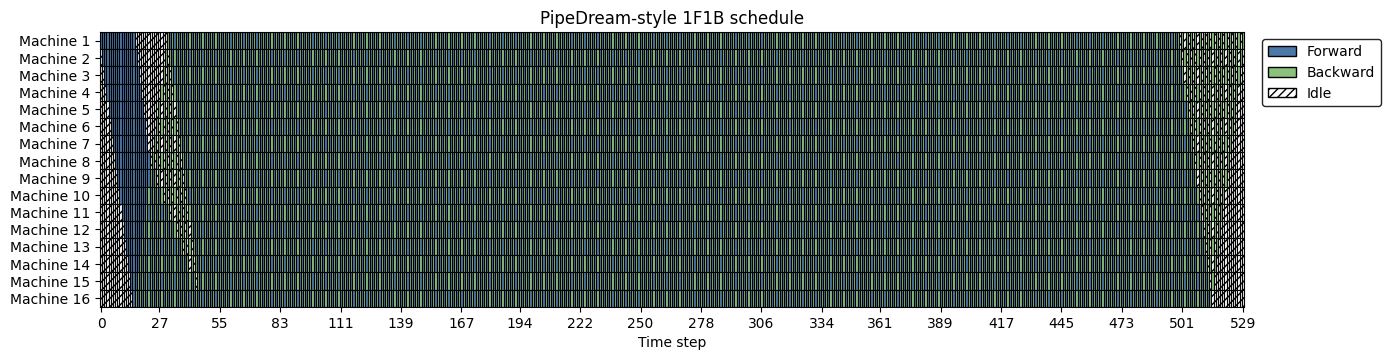

In [5]:
fig, ax = plot_schedule(timeline, startup_boundary=None, reduce_text=True, max_xtick_labels=20)
plt.show()

In [13]:
pd_gamma_grid = (2.0 ** np.arange(-12, -2))

print("L =", L)
print("gamma min =", pd_gamma_grid[0])
print("gamma max =", pd_gamma_grid[-1])
print("1/L =", 1.0 / L)

pd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="PipeDream",
    learning_rates=pd_gamma_grid,
    method_factory_builder=lambda lr, seed: make_pd_method(
        lr=lr,
        timeline=timeline,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        name=f"PipeDream lr={lr:.6e}",
    ),
    seeds=[0],
    K_budget=K_budget,
)

print("Best PipeDream lr =", pd_sweep["best_lr"])
print("Best PipeDream lr * L =", pd_sweep["best_lr"] * L)

L = 13.54012915911477
gamma min = 0.000244140625
gamma max = 0.125
1/L = 0.0738545392181014
Best PipeDream lr = 0.015625
Best PipeDream lr * L = 0.21156451811116828


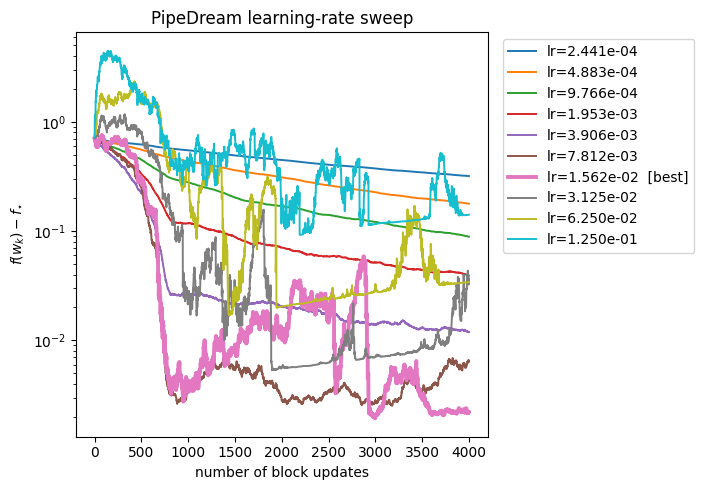

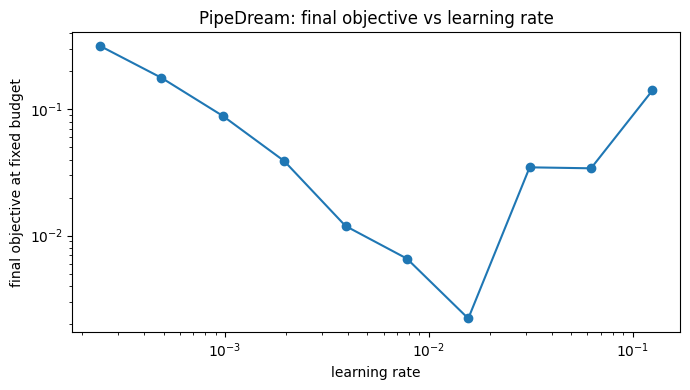

In [14]:
plot_lr_sweep_curves(
    pd_sweep,
    title="PipeDream learning-rate sweep",
    log_scale=True,
)

plot_lr_sweep_summary(
    pd_sweep,
    title="PipeDream: final objective vs learning rate",
)

In [534]:
gpd_gamma_grid = (2.0 ** np.arange(-8, 0))

gpd_sweep = sweep_learning_rates(
    objective=objective,
    method_name="GPD",
    learning_rates=gpd_gamma_grid,
    method_factory_builder=lambda lr, seed: make_gpd_method(
        lr=lr,
        K_budget=K_budget,
        delta=delta_gpd,
        training_batch_indices=training_batch_indices,
        init_stage_weights=init_stage_weights,
        seed=seed,
        name=f"GPD lr={lr:.6e}",
    ),
    seeds=[0],
    K_budget=K_budget,
)

print("Best GPD lr =", gpd_sweep["best_lr"])
print("Best GPD lr * L =", gpd_sweep["best_lr"] * L)

Best GPD lr = 0.03125
Best GPD lr * L = 0.42312903622233655


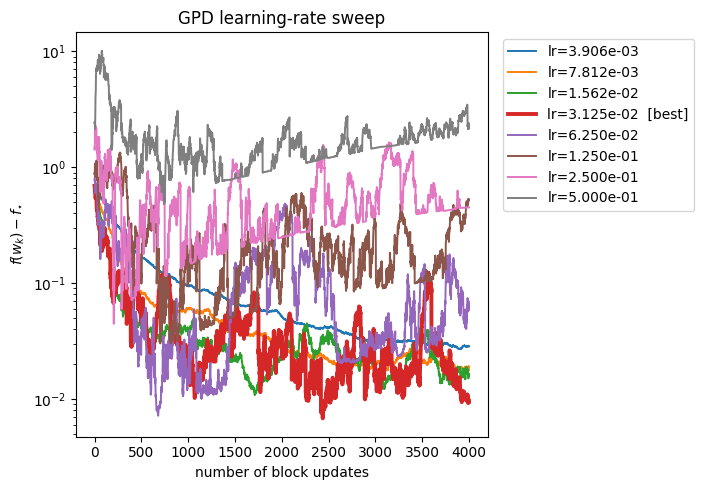

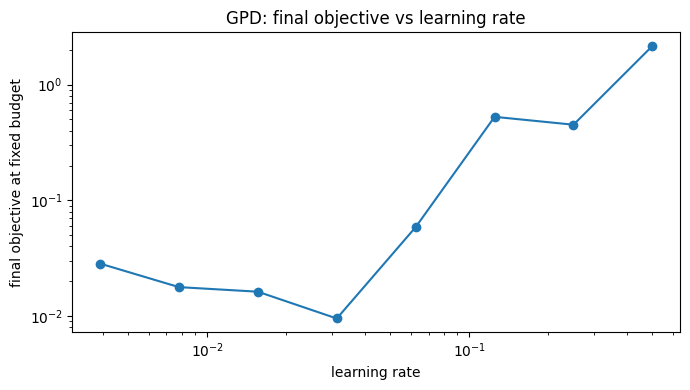

In [535]:
plot_lr_sweep_curves(
    gpd_sweep,
    title="GPD learning-rate sweep",
    log_scale=True,
)

plot_lr_sweep_summary(
    gpd_sweep,
    title="GPD: final objective vs learning rate",
)

PipeDream final-point best lr: 3.125e-02
PipeDream stable selected lr: 3.125e-02
GPD final-point best lr: 1.562e-02
GPD stable selected lr: 1.562e-02


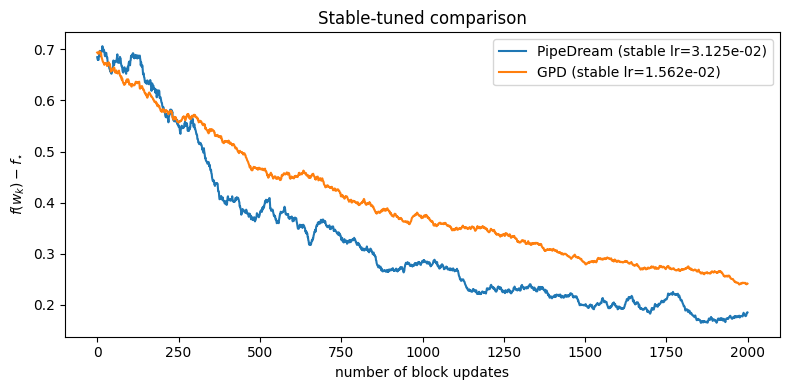

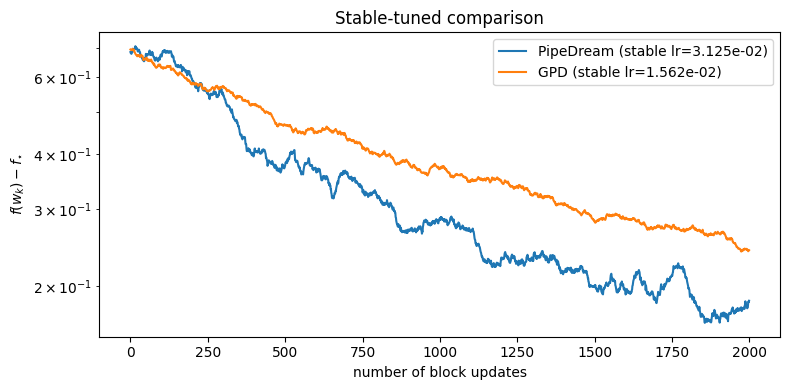

In [492]:
stable_pd_lr, pd_lr_table = select_stable_learning_rate(
    pd_sweep,
    tail_frac=0.2,
    relative_tol=0.05,
    max_tail_cv=0.15,
    max_up_fraction=0.45,
    max_up_rel=0.05,
    max_tv_ratio=5.0,
    max_tail_log_slope=1e-4,
    prefer="smaller",
)

stable_gpd_lr, gpd_lr_table = select_stable_learning_rate(
    gpd_sweep,
    tail_frac=1,
    relative_tol=0.05,
    max_tail_cv=0.15,
    max_up_fraction=0.45,
    max_up_rel=0.05,
    max_tv_ratio=5.0,
    max_tail_log_slope=1e-4,
    prefer="smaller",
)

selected_pd_curve = pd_sweep["results"][stable_pd_lr]["mean_curve"]
selected_gpd_curve = gpd_sweep["results"][stable_gpd_lr]["mean_curve"]

T = min(len(selected_pd_curve), len(selected_gpd_curve))

print(f"PipeDream final-point best lr: {pd_sweep['best_lr']:.3e}")
print(f"PipeDream stable selected lr: {stable_pd_lr:.3e}")
print(f"GPD final-point best lr: {gpd_sweep['best_lr']:.3e}")
print(f"GPD stable selected lr: {stable_gpd_lr:.3e}")

plt.figure(figsize=(8, 4))
plt.plot(
    selected_pd_curve[:T],
    label=f"PipeDream (stable lr={stable_pd_lr:.3e})",
)
plt.plot(
    selected_gpd_curve[:T],
    label=f"GPD (stable lr={stable_gpd_lr:.3e})",
)
plt.xlabel("number of block updates")
plt.ylabel(r"$f(w_k) - f_{\star}$")
plt.title("Stable-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
eps = 1e-16
plt.semilogy(
    np.maximum(selected_pd_curve[:T], eps),
    label=f"PipeDream (stable lr={stable_pd_lr:.3e})",
)
plt.semilogy(
    np.maximum(selected_gpd_curve[:T], eps),
    label=f"GPD (stable lr={stable_gpd_lr:.3e})",
)
plt.xlabel("number of block updates")
plt.ylabel(r"$f(w_k) - f_{\star}$")
plt.title("Stable-tuned comparison")
plt.legend()
plt.tight_layout()
plt.show()

## GPD comparison for multiple values of $\delta$

The cells below repeat the GPD learning-rate sweep for several different delay bounds
and then compare the best-tuned GPD curve for each $\delta$ against PipeDream.
This lets us see how sensitive the approximation is to the choice of $\delta$.

In [493]:
# choose several delta values to compare
raw_delta_candidates = [
    ("8", 8),
    (r"S", max(30, num_stages)),
    (r"S^2 - S/2", max(1, num_stages**2 - num_stages // 2)),
    (r"180", 180),
    (r"420", 420),
]

delta_candidates = []
seen = set()
for label, delta in raw_delta_candidates:
    if delta not in seen:
        delta_candidates.append((label, int(delta)))
        seen.add(int(delta))

print("delta candidates:")
for label, delta in delta_candidates:
    print(f"  {label:>10s} -> {delta}")

delta candidates:
           8 -> 8
           S -> 30
   S^2 - S/2 -> 60
         180 -> 180
         420 -> 420


In [476]:
gpd_sweeps_by_delta = {}

for delta_label, delta_value in delta_candidates:
    print(f"Running RPD sweep for delta={delta_label} ({delta_value})")

    sweep = sweep_learning_rates(
        objective=objective,
        method_name=f"RPD delta={delta_label}",
        learning_rates=gpd_gamma_grid,
        method_factory_builder=lambda lr, seed, delta_value=delta_value, delta_label=delta_label: make_gpd_method(
            lr=lr,
            K_budget=K_budget,
            delta=delta_value,
            training_batch_indices=training_batch_indices,
            init_stage_weights=init_stage_weights,
            seed=seed,
            name=f"RPD delta={delta_label} lr={lr:.6e}",
        ),
        seeds=[0],
        K_budget=K_budget,
    )

    gpd_sweeps_by_delta[delta_value] = {
        "label": delta_label,
        "sweep": sweep,
    }

    print(
        f"best lr = {sweep['best_lr']:.6e}, "
        f"best lr * L = {sweep['best_lr'] * L:.6e}, "
        f"final objective = {sweep['results'][sweep['best_lr']]['final_mean']:.6e}"
    )

Running RPD sweep for delta=8 (8)
best lr = 1.250000e-01, best lr * L = 4.622449e-01, final objective = 5.647896e-02
Running RPD sweep for delta=S (30)
best lr = 2.500000e-01, best lr * L = 9.244899e-01, final objective = 6.912331e-02
Running RPD sweep for delta=S^2 - S/2 (60)
best lr = 1.250000e-01, best lr * L = 4.622449e-01, final objective = 7.211352e-02
Running RPD sweep for delta=180 (180)
best lr = 6.250000e-02, best lr * L = 2.311225e-01, final objective = 7.254895e-02
Running RPD sweep for delta=420 (420)
best lr = 1.250000e-01, best lr * L = 4.622449e-01, final objective = 2.859236e-02


delta=8: final-point best lr=1.250e-01, lr=1.250e-01
delta=S: final-point best lr=2.500e-01, lr=3.125e-02
delta=S^2 - S/2: final-point best lr=1.250e-01, lr=1.250e-01
delta=180: final-point best lr=6.250e-02, lr=2.500e-01
delta=420: final-point best lr=1.250e-01, lr=1.250e-01


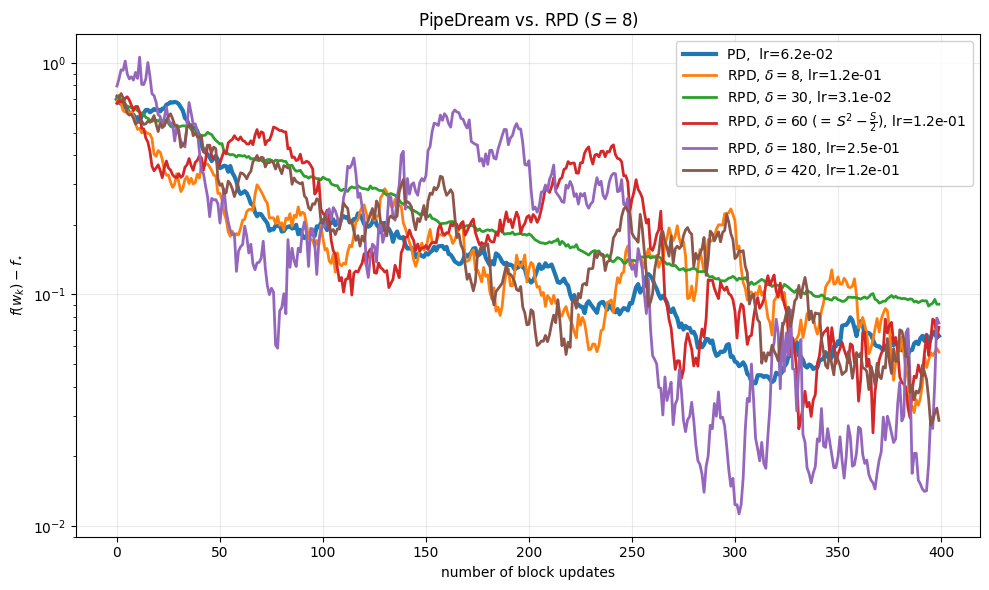

In [477]:
stable_pd_lr, pd_lr_table = select_stable_learning_rate(
    pd_sweep,
    tail_frac=0.2,
    relative_tol=0.05,
    max_tail_cv=0.15,
    max_up_fraction=0.45,
    max_up_rel=0.05,
    max_tv_ratio=5.0,
    max_tail_log_slope=1e-4,
    prefer="smaller",
)

stable_pd_curve = pd_sweep["results"][stable_pd_lr]["mean_curve"]

special_delta_value = num_stages**2 - num_stages / 2
eps = 1e-16


def format_delta_label(delta_value, special_delta_value):
    delta_int = int(round(delta_value))
    if np.isclose(delta_value, special_delta_value):
        return rf"{delta_int}\;(=\,S^2-\frac{{S}}{{2}})"
    return f"{delta_int}"


selected_gpd_by_delta = {}

for delta_value, info in gpd_sweeps_by_delta.items():
    sweep = info["sweep"]

    stable_gpd_lr, gpd_lr_table = select_stable_learning_rate(
        sweep,
        tail_frac=0.2,
        relative_tol=0.05,
        max_tail_cv=0.15,
        max_up_fraction=0.45,
        max_up_rel=0.05,
        max_tv_ratio=5.0,
        max_tail_log_slope=1e-4,
        prefer="smaller",
    )

    selected_gpd_by_delta[delta_value] = {
        "label": info["label"],
        "sweep": sweep,
        "stable_lr": stable_gpd_lr,
        "stable_curve": sweep["results"][stable_gpd_lr]["mean_curve"],
        "lr_table": gpd_lr_table,
    }

    print(
        f"delta={info['label']}: "
        f"final-point best lr={sweep['best_lr']:.3e}, "
        f"lr={stable_gpd_lr:.3e}"
    )


T = min(
    len(stable_pd_curve),
    *[
        len(info["stable_curve"])
        for info in selected_gpd_by_delta.values()
    ],
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogy(
    np.maximum(stable_pd_curve[:T], eps),
    linewidth=3.0,
    label=rf"PD,  lr={stable_pd_lr:.1e}",
)

for delta_value, info in selected_gpd_by_delta.items():
    curve = info["stable_curve"]
    stable_gpd_lr = info["stable_lr"]
    delta_text = format_delta_label(delta_value, special_delta_value)

    ax.semilogy(
        np.maximum(curve[:T], eps),
        linewidth=2.0,
        label=rf"RPD, $\delta={delta_text}$, lr={stable_gpd_lr:.1e}",
    )

ax.set_xlabel("number of block updates")
ax.set_ylabel(r"$f(w_k) - f_{\star}$")
ax.set_title(r"PipeDream vs. RPD $(S=8)$")

ax.legend(
    loc="upper right",
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    borderpad=0.5,
    labelspacing=0.35,
    handlelength=2.4,
)

ax.grid(True, alpha=0.25)
fig.tight_layout()
plt.savefig("pd_vs_RPD_different_delta.pdf", bbox_inches="tight")
plt.show()

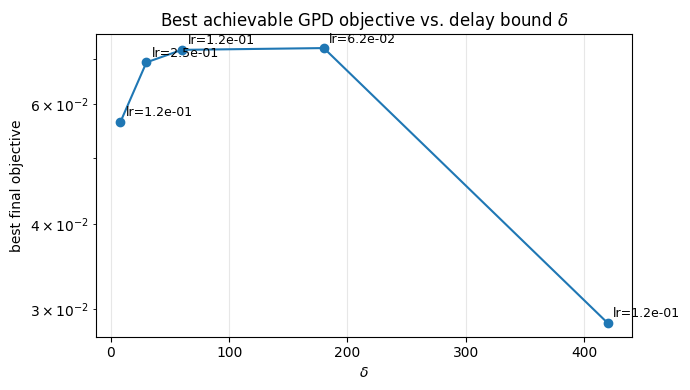

In [478]:
# summarize how the best achievable final objective depends on delta
delta_values = []
best_final_objectives = []
best_lrs_by_delta = []

for delta_value, info in sorted(gpd_sweeps_by_delta.items(), key=lambda x: x[0]):
    sweep = info["sweep"]
    best_lr = sweep["best_lr"]
    best_final = sweep["results"][best_lr]["final_mean"]

    delta_values.append(delta_value)
    best_final_objectives.append(best_final)
    best_lrs_by_delta.append(best_lr)

delta_values = np.asarray(delta_values)
best_final_objectives = np.asarray(best_final_objectives)
best_lrs_by_delta = np.asarray(best_lrs_by_delta)

plt.figure(figsize=(7, 4))
plt.semilogy(delta_values, best_final_objectives, marker="o")
for x, y, lr in zip(delta_values, best_final_objectives, best_lrs_by_delta):
    plt.annotate(f"lr={lr:.1e}", (x, y), textcoords="offset points", xytext=(4, 4), fontsize=9)
plt.xlabel(r"$\delta$")
plt.ylabel("best final objective")
plt.title(r"Best achievable GPD objective vs. delay bound $\delta$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("best_gpd_vs_delta.pdf", bbox_inches="tight")
plt.show()

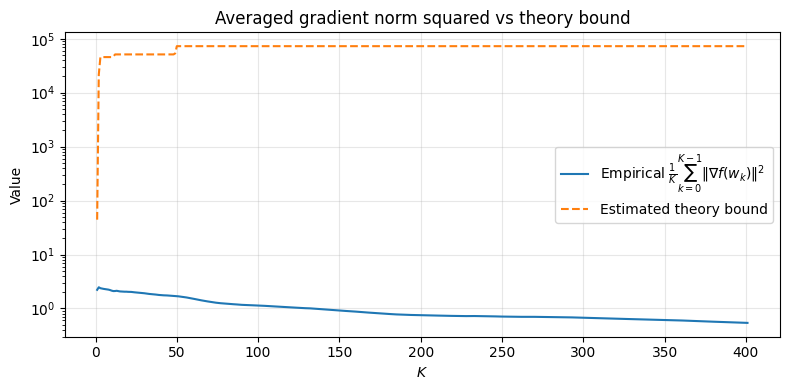

In [479]:
best_trace = gpd_sweep['results'][gpd_sweep['best_lr']]
traces = best_trace['traces']

avg_grad_curves = np.stack(
    [tr.avg_full_grad_norm_sq_trace for tr in traces],
    axis=0,
)
avg_grad_mean = avg_grad_curves.mean(axis=0)
avg_grad_std = avg_grad_curves.std(axis=0)

bound_curves = np.stack(
    [tr.theory_bound_trace for tr in traces],
    axis=0,
)
bound_mean = bound_curves.mean(axis=0)
bound_std = bound_curves.std(axis=0)

x = np.arange(1, len(avg_grad_mean) + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x, avg_grad_mean, label=r"Empirical $\frac{1}{K}\sum_{k=0}^{K-1}\|\nabla f(w_k)\|^2$")
ax.fill_between(
    x,
    avg_grad_mean - avg_grad_std,
    avg_grad_mean + avg_grad_std,
    alpha=0.2,
)

ax.plot(x, bound_mean, linestyle="--", label=r"Estimated theory bound")
ax.fill_between(
    x,
    bound_mean - bound_std,
    bound_mean + bound_std,
    alpha=0.2,
)

ax.set_yscale("log")
ax.set_xlabel(r"$K$")
ax.set_ylabel("Value")
ax.set_title("Averaged gradient norm squared vs theory bound")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

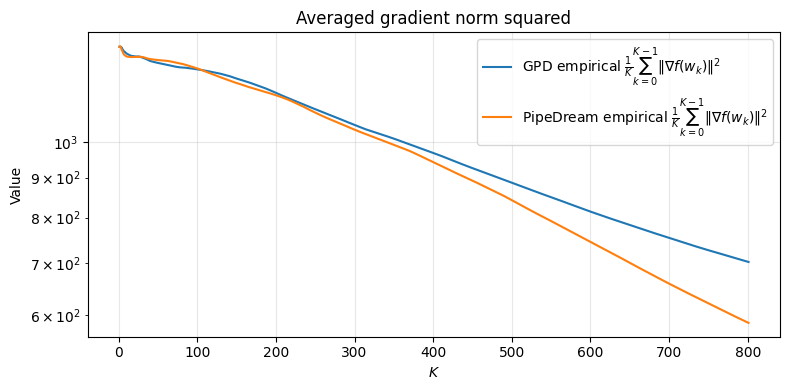

In [433]:
best_trace_gpd = gpd_sweep['results'][gpd_sweep['best_lr']]
gpd_traces = best_trace_gpd['traces']

avg_grad_curves_gpd = np.stack(
    [tr.avg_full_grad_norm_sq_trace for tr in gpd_traces],
    axis=0,
)
avg_grad_mean_gpd = avg_grad_curves_gpd.mean(axis=0)
avg_grad_std_gpd = avg_grad_curves_gpd.std(axis=0)

bound_curves_gpd = np.stack(
    [tr.theory_bound_trace for tr in gpd_traces],
    axis=0,
)
bound_mean_gpd = bound_curves_gpd.mean(axis=0)
bound_std_gpd = bound_curves_gpd.std(axis=0)


best_trace_pd = pd_sweep['results'][pd_sweep['best_lr']]
pd_traces = best_trace_pd['traces']

avg_grad_curves_pd = np.stack(
    [tr.avg_full_grad_norm_sq_trace for tr in pd_traces],
    axis=0,
)
avg_grad_mean_pd = avg_grad_curves_pd.mean(axis=0)
avg_grad_std_pd = avg_grad_curves_pd.std(axis=0)


x_gpd = np.arange(1, len(avg_grad_mean_gpd) + 1)
x_pd = np.arange(1, len(avg_grad_mean_pd) + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    x_gpd,
    avg_grad_mean_gpd,
    label=r"GPD empirical $\frac{1}{K}\sum_{k=0}^{K-1}\|\nabla f(w_k)\|^2$",
)
ax.fill_between(
    x_gpd,
    avg_grad_mean_gpd - avg_grad_std_gpd,
    avg_grad_mean_gpd + avg_grad_std_gpd,
    alpha=0.2,
)
'''
ax.plot(
    x_gpd,
    bound_mean_gpd,
    linestyle="--",
    label=r"GPD estimated theory bound",
)
ax.fill_between(
    x_gpd,
    bound_mean_gpd - bound_std_gpd,
    bound_mean_gpd + bound_std_gpd,
    alpha=0.2,
)'''

ax.plot(
    x_pd,
    avg_grad_mean_pd,
    label=r"PipeDream empirical $\frac{1}{K}\sum_{k=0}^{K-1}\|\nabla f(w_k)\|^2$",
)
ax.fill_between(
    x_pd,
    avg_grad_mean_pd - avg_grad_std_pd,
    avg_grad_mean_pd + avg_grad_std_pd,
    alpha=0.2,
)

ax.set_yscale("log")
ax.set_xlabel(r"$K$")
ax.set_ylabel("Value")
ax.set_title("Averaged gradient norm squared")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()

# Scaling of PD, RPD and LocalSGD with $S$

In [6]:
# Fixed-time scaling experiment:
# final objective value vs number of stages S
# Learning rates are selected using stable stepsize selection.
#
# Fairness rule: We strictly fix the TIMELINE LENGTH across all methods and S.
# We evaluate progress based on `objective_trace` (Time Steps) rather than model updates.

import numpy as np
from src.schedulers.independent_local_sgd_pipeline import IndependentLocalSGDScheduler
from src.methods.localSGD import LocalMinibatchSGD1F1BMethod

# =========================================================================
# UPDATED AGGREGATORS (No K_budget)
# =========================================================================
def aggregate_time_curves(traces, tail_frac=0.01):
    curves = []
    for tr in traces:
        # We now use the trace that records the objective at every single Time Step
        curve = tr.objective_trace
        if curve is None:
            raise ValueError(f"{tr.method_name} has no objective_trace.")
        curves.append(curve)
        
    curves = np.stack(curves, axis=0)
    tail_len = max(1, int(curves.shape[1] * tail_frac))
    
    return {
        "mean": curves.mean(axis=0),
        "std": curves.std(axis=0),
        "final_mean": float(curves[:, -1].mean()),
        "final_std": float(curves[:, -1].std()),
        "tail_mean": float(curves[:, -tail_len:].mean()),  # Needed for stable LR selection
        "tail_std": float(curves[:, -tail_len:].std()),
        "all": curves,
    }

def sweep_learning_rates(
    objective,
    method_name: str,
    learning_rates,
    method_factory_builder,
    seeds,
):
    results = {}

    for lr in learning_rates:
        traces = run_trials(
            objective=objective,
            method_factory=lambda seed, lr=lr: method_factory_builder(lr, seed),
            seeds=seeds,
        )
        agg = aggregate_time_curves(traces)
        results[float(lr)] = {
            "traces": traces,
            "mean_curve": agg["mean"],
            "std_curve": agg["std"],
            "final_mean": agg["final_mean"],
            "final_std": agg["final_std"],
            "tail_mean": agg["tail_mean"],
            "tail_std": agg["tail_std"],
        }

    best_lr = min(results.keys(), key=lambda lr: results[lr]["final_mean"])
    return {
        "method_name": method_name,
        "results": results,
        "best_lr": best_lr,
        "best_curve": results[best_lr]["mean_curve"],
        "best_std": results[best_lr]["std_curve"],
    }

# =========================================================================
# HELPER FUNCTIONS
# =========================================================================
def make_local_sgd_method(
    lr: float, timeline, num_runs: int, local_steps: int, 
    training_batch_indices, init_stage_weights, name: str | None = None
):
    return LocalMinibatchSGD1F1BMethod(
        timeline=timeline, learning_rate=lr, training_batch_indices=training_batch_indices,
        num_runs=num_runs, local_steps=local_steps, init_stage_weights=init_stage_weights,
        name=name or f"Local SGD lr={lr:.3e}",
    )

def find_optimal_microbatches(scheduler_gen_fn, target_length):
    """Binary searches for the smallest number of microbatches to reach the target timeline length."""
    high = 1
    while len(scheduler_gen_fn(high)) < target_length:
        high *= 2
        
    low = high // 2
    best_N = high
    best_timeline = scheduler_gen_fn(high)
    
    while low <= high:
        mid = (low + high) // 2
        timeline = scheduler_gen_fn(mid)
        if len(timeline) >= target_length:
            best_N = mid
            best_timeline = timeline
            high = mid - 1
        else:
            low = mid + 1
            
    return best_N, best_timeline

In [ ]:
stage_counts = 2**np.arange(1, 8)
print(stage_counts)
num_parameters = 512
S_ref = stage_counts[0]

# --- STRICT FIXED WALL-CLOCK BUDGET ---
target_timeline_length = len(timeline)*6

stage_scaling_seeds = [0]
local_sgd_local_steps = 5
gradient_noise_std = 0.5

stage_scaling_pd_gamma_grid = (2.0 ** np.arange(-12, -2))
stage_scaling_rpd_gamma_grid = (2.0 ** np.arange(-12, -2))
stage_scaling_local_sgd_gamma_grid = (2.0 ** np.arange(-8, 3))

stage_scaling_results = {}

for S in stage_counts:
    print(f"\nRunning fixed-time scaling experiment for S={S}")

    delta_rpd = int(S**2 - S / 2)
    #delta_rpd = int(S**2 / 4)
    local_sgd_M_s = S
    local_sgd_K_s = local_sgd_local_steps

    objective_s = LogisticRegressionObjective.synthetic(
        num_examples=num_examples, num_parameters=num_parameters, num_stages=S,
        batch_size=batch_size, seed=seed, l2_reg=1e-4, gradient_noise_std=gradient_noise_std
    )

    init_stage_weights_s = objective_s.initial_stage_weights(mode="zeros", seed=0)
    num_dataset_batches_s = len(objective_s.get_batches())

    # -------------------------------------------------------------------------
    # 1. FIND TIMELINES (Strictly Truncated to exact Target Length)
    # -------------------------------------------------------------------------
    pd_scheduler_s = PipeDream1F1BScheduler(noam=S)
    pd_microbatches, pd_timeline_s = find_optimal_microbatches(
        lambda N: pd_scheduler_s.generate(num_stages=S, num_microbatches=N),
        target_length=target_timeline_length
    )
    #pd_timeline_s = pd_timeline_s[:target_timeline_length]  # EXACT Truncation

    pd_training_batch_indices_s = build_training_batch_schedule(
        num_dataset_batches=num_dataset_batches_s, num_microbatches=pd_microbatches,
        shuffle_each_epoch=False, seed=seed + 1,
    )

    local_sgd_scheduler_s = IndependentLocalSGDScheduler(num_runs=local_sgd_M_s, local_steps=local_sgd_K_s)
    local_sgd_microbatches, local_sgd_timeline_s = find_optimal_microbatches(
        lambda N: local_sgd_scheduler_s.generate(num_stages=S, num_microbatches=N),
        target_length=target_timeline_length
    )
    #local_sgd_timeline_s = local_sgd_timeline_s[:target_timeline_length] # EXACT Truncation

    local_sgd_training_batch_indices_s = build_training_batch_schedule(
        num_dataset_batches=num_dataset_batches_s, num_microbatches=local_sgd_microbatches,
        shuffle_each_epoch=False, seed=seed + 1,
    )

    print(f"Target Budget Length = {target_timeline_length} time steps")
    print(f"PipeDream Timeline = {len(pd_timeline_s)} steps (N={pd_microbatches})")
    print(f"Local SGD Timeline = {len(local_sgd_timeline_s)} steps (N={local_sgd_microbatches})")
    print(f"RPD delta = {delta_rpd}")
    print(f"Local Minibatch SGD M = {local_sgd_M_s}, K = {local_sgd_K_s}")


    rpd_iterations_s = sum(
        1 
        for step in pd_timeline_s 
        for op in step 
        if op is not None and op[0] == 'B'
    )

    print(f"Number of block updates for PD/RPD = {rpd_iterations_s}")

    
    # -------------------------------------------------------------------------
    # 2. RUN SWEEPS (No Probes needed, no K_budget passed)
    # -------------------------------------------------------------------------
    pd_sweep_s = sweep_learning_rates(
        objective=objective_s, 
        method_name=f"PipeDream S={S}", 
        learning_rates=stage_scaling_pd_gamma_grid,
        method_factory_builder=lambda lr, trial_seed, tl=pd_timeline_s, idx=pd_training_batch_indices_s, w=init_stage_weights_s: PipeDreamMethod(
            timeline=tl, learning_rate=lr, training_batch_indices=idx, init_stage_weights=w, name=f"PD S={S} lr={lr:.6e}"
        ),
        seeds=stage_scaling_seeds,
    )

    rpd_sweep_s = sweep_learning_rates(
        objective=objective_s, method_name=f"RPD S={S}", learning_rates=stage_scaling_rpd_gamma_grid,
        method_factory_builder=lambda lr, trial_seed, idx=pd_training_batch_indices_s, w=init_stage_weights_s: GPDMethod(
            num_iterations=rpd_iterations_s, learning_rate=lr, delta=delta_rpd, seed=trial_seed, 
            training_batch_indices=idx, init_stage_weights=w, name=f"RPD S={S} delta={delta_rpd} lr={lr:.6e}"
        ),
        seeds=stage_scaling_seeds,
    )
    
    local_sgd_sweep_s = sweep_learning_rates(
        objective=objective_s, method_name=f"Local SGD S={S}", learning_rates=stage_scaling_local_sgd_gamma_grid,
        method_factory_builder=lambda lr, trial_seed, tl=local_sgd_timeline_s, idx=local_sgd_training_batch_indices_s, w=init_stage_weights_s: make_local_sgd_method(
            lr=lr, timeline=tl, num_runs=local_sgd_M_s, local_steps=local_sgd_K_s, 
            training_batch_indices=idx, init_stage_weights=w, name=f"LSGD S={S} M={local_sgd_M_s} K={local_sgd_K_s} lr={lr:.6e}"
        ),
        seeds=stage_scaling_seeds,
    )

    # -------------------------------------------------------------------------
    # 3. SELECT STABLE LEARNING RATES
    # -------------------------------------------------------------------------
    stable_pd_lr_s, pd_lr_table_s = select_stable_learning_rate(pd_sweep_s, tail_frac=0.01, relative_tol=0.05, max_tail_cv=0.15, max_up_fraction=0.45, max_up_rel=0.05, max_tv_ratio=5.0, max_tail_log_slope=1e-4, prefer="smaller")
    stable_rpd_lr_s, rpd_lr_table_s = select_stable_learning_rate(rpd_sweep_s, tail_frac=0.01, relative_tol=0.05, max_tail_cv=0.15, max_up_fraction=0.45, max_up_rel=0.05, max_tv_ratio=5.0, max_tail_log_slope=1e-4, prefer="smaller")
    stable_local_sgd_lr_s, local_sgd_lr_table_s = select_stable_learning_rate(local_sgd_sweep_s, tail_frac=0.01, relative_tol=0.05, max_tail_cv=0.15, max_up_fraction=0.45, max_up_rel=0.05, max_tv_ratio=5.0, max_tail_log_slope=1e-4, prefer="smaller")

    # Save Results
    stage_scaling_results[S] = {
        "S": S,
        "K_budget": target_timeline_length,
        "delta_rpd": delta_rpd,
        "pd_microbatches": pd_microbatches,
        "local_sgd_microbatches": local_sgd_microbatches,
        
        "pd_timeline": pd_timeline_s,
        "rpd_timeline": pd_timeline_s,
        "local_sgd_timeline": local_sgd_timeline_s,

        "pd_sweep": pd_sweep_s,
        "rpd_sweep": rpd_sweep_s,
        "local_sgd_sweep": local_sgd_sweep_s,

        "pd_selected_lr": stable_pd_lr_s,
        "rpd_selected_lr": stable_rpd_lr_s,
        "local_sgd_selected_lr": stable_local_sgd_lr_s,

        "pd_final": pd_sweep_s["results"][stable_pd_lr_s]["final_mean"],
        "rpd_final": rpd_sweep_s["results"][stable_rpd_lr_s]["final_mean"],
        "local_sgd_final": local_sgd_sweep_s["results"][stable_local_sgd_lr_s]["final_mean"],
    }

    print(
        f"PipeDream: final-best lr={pd_sweep_s['best_lr']:.3e}, "
        f"selected lr={stable_pd_lr_s:.3e}, "
        f"final={pd_sweep_s['results'][stable_pd_lr_s]['final_mean']:.6e}"
    )

    print(
        f"RPD:       final-best lr={rpd_sweep_s['best_lr']:.3e}, "
        f"selected lr={stable_rpd_lr_s:.3e}, "
        f"final={rpd_sweep_s['results'][stable_rpd_lr_s]['final_mean']:.6e}"
    )

    print(
        f"Local SGD: final-best lr={local_sgd_sweep_s['best_lr']:.3e}, "
        f"selected lr={stable_local_sgd_lr_s:.3e}, "
        f"final={local_sgd_sweep_s['results'][stable_local_sgd_lr_s]['final_mean']:.6e}"
    )

[  2   4   8  16  32  64 128]

Running fixed-time scaling experiment for S=2
Target Budget Length = 3180 time steps
PipeDream Timeline = 3180 steps (N=1589)
Local SGD Timeline = 3180 steps (N=1445)
RPD delta = 3
Local Minibatch SGD M = 2, K = 5
Number of block updates for PD/RPD = 3178
PipeDream: final-best lr=1.562e-02, selected lr=1.562e-02, final=1.078025e-02
RPD:       final-best lr=1.562e-02, selected lr=7.812e-03, final=1.515086e-02
Local SGD: final-best lr=6.250e-02, selected lr=1.562e-02, final=1.312029e-02

Running fixed-time scaling experiment for S=4
Target Budget Length = 3180 time steps
PipeDream Timeline = 3180 steps (N=1587)
Local SGD Timeline = 3182 steps (N=1381)
RPD delta = 14
Local Minibatch SGD M = 4, K = 5
Number of block updates for PD/RPD = 6348


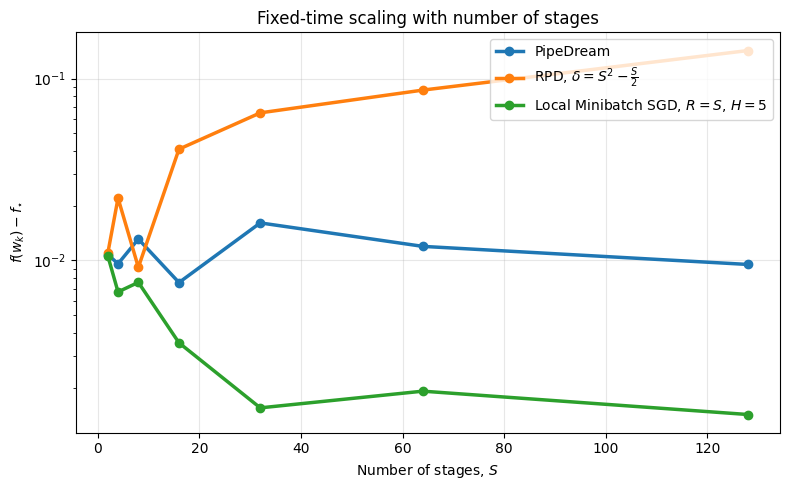

Summary:
S= 2 | K=  3180 | delta=    1 | PipeDream final=1.078025e-02, lr=1.562e-02 | RPD final=1.101584e-02, lr=7.812e-03 | Local SGD final=1.058456e-02, lr=3.125e-02
S= 4 | K=  3180 | delta=    4 | PipeDream final=9.591105e-03, lr=1.562e-02 | RPD final=2.202399e-02, lr=7.812e-03 | Local SGD final=6.716137e-03, lr=6.250e-02
S= 8 | K=  3180 | delta=   16 | PipeDream final=1.312390e-02, lr=1.562e-02 | RPD final=9.172471e-03, lr=3.125e-02 | Local SGD final=7.580440e-03, lr=1.250e-01
S=16 | K=  3180 | delta=   64 | PipeDream final=7.562785e-03, lr=1.562e-02 | RPD final=4.096462e-02, lr=6.250e-02 | Local SGD final=3.524696e-03, lr=2.500e-01
S=32 | K=  3180 | delta=  256 | PipeDream final=1.609685e-02, lr=7.812e-03 | RPD final=6.487817e-02, lr=3.125e-02 | Local SGD final=1.546655e-03, lr=2.500e-01
S=64 | K=  3180 | delta= 1024 | PipeDream final=1.195706e-02, lr=1.562e-02 | RPD final=8.654330e-02, lr=6.250e-02 | Local SGD final=1.910766e-03, lr=2.500e-01
S=128 | K=  3180 | delta= 4096 | Pipe

In [32]:
S_values = np.array(sorted(stage_scaling_results.keys()))

pd_final_values = np.array([
    stage_scaling_results[S]["pd_final"]
    for S in S_values
])

rpd_final_values = np.array([
    stage_scaling_results[S]["rpd_final"]
    for S in S_values
])

local_sgd_final_values = np.array([
    stage_scaling_results[S]["local_sgd_final"]
    for S in S_values
])

eps = 1e-16

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(
    S_values,
    np.maximum(pd_final_values, eps),
    marker="o",
    linewidth=2.5,
    label="PipeDream",
)

ax.semilogy(
    S_values,
    np.maximum(rpd_final_values, eps),
    marker="o",
    linewidth=2.5,
    label=r"RPD, $\delta=S^2-\frac{S}{2}$",
)

ax.semilogy(
    S_values,
    np.maximum(local_sgd_final_values, eps),
    marker="o",
    linewidth=2.5,
    label=rf"Local Minibatch SGD, $R=S$, $H={local_sgd_local_steps}$",
)

ax.set_xscale("linear")
ax.set_xlabel(r"Number of stages, $S$")
ax.set_ylabel(r"$f(w_k) - f_{\star}$")
ax.set_title(r"Fixed-time scaling with number of stages")

#ax.set_xticks(S_values)
ax.grid(True, alpha=0.3)
ax.legend()

#ax.set_ylim(1e-3, 1e1)

fig.tight_layout()
plt.savefig("fixed_time_scaling_vs_stages_three_methods.pdf", bbox_inches="tight")
plt.show()


print("Summary:")
for S in S_values:
    row = stage_scaling_results[S]

    print(
        f"S={S:2d} | "
        f"K={row['K_budget']:6d} | "
        f"delta={row['delta_rpd']:5d} | "
        f"PipeDream final={row['pd_final']:.6e}, lr={row['pd_selected_lr']:.3e} | "
        f"RPD final={row['rpd_final']:.6e}, lr={row['rpd_selected_lr']:.3e} | "
        f"Local SGD final={row['local_sgd_final']:.6e}, lr={row['local_sgd_selected_lr']:.3e}"
    )

In [8]:
pd_timeline_s

[[('F', 0), None, None, None],
 [('F', 1), ('F', 0), None, None],
 [('F', 2), ('F', 1), ('F', 0), None],
 [('F', 3), ('F', 2), ('F', 1), ('F', 0)],
 [None, ('F', 3), ('F', 2), ('B', 0)],
 [None, None, ('B', 0), ('F', 1)],
 [None, ('B', 0), ('F', 3), ('B', 1)],
 [('B', 0), None, ('B', 1), ('F', 2)],
 [('F', 4), ('B', 1), None, ('B', 2)],
 [('B', 1), ('F', 4), ('B', 2), ('F', 3)],
 [('F', 5), ('B', 2), ('F', 4), ('B', 3)],
 [('B', 2), ('F', 5), ('B', 3), ('F', 4)],
 [('F', 6), ('B', 3), ('F', 5), ('B', 4)],
 [('B', 3), ('F', 6), ('B', 4), ('F', 5)],
 [('F', 7), ('B', 4), ('F', 6), ('B', 5)],
 [('B', 4), ('F', 7), ('B', 5), ('F', 6)],
 [('F', 8), ('B', 5), ('F', 7), ('B', 6)],
 [('B', 5), ('F', 8), ('B', 6), ('F', 7)],
 [('F', 9), ('B', 6), ('F', 8), ('B', 7)],
 [('B', 6), ('F', 9), ('B', 7), ('F', 8)],
 [('F', 10), ('B', 7), ('F', 9), ('B', 8)],
 [('B', 7), ('F', 10), ('B', 8), ('F', 9)],
 [('F', 11), ('B', 8), ('F', 10), ('B', 9)],
 [('B', 8), ('F', 11), ('B', 9), ('F', 10)],
 [('F', 12

In [9]:
rpd_iterations_s = sum(
        1 
        for step in pd_timeline_s 
        for op in step 
        if op is not None and op[0] == 'B'
    )

In [10]:
rpd_iterations_s

6348